In [39]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"

df = pd.read_csv(url)

In [40]:
df.head()

,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


In [41]:
years = sorted(df["Year"].unique())
ratings_yr = [df.loc[df["Year"] == year, "Rating"]for year in years]
f, p = stats.f_oneway(*ratings_yr)
dfb = len(years) - 1
dfw = len(df) - len(years)
alpha = 0.05
critical = stats.f.ppf(1 - alpha, dfb, dfw)
print(f"f: {f:.4f}", f"critical: {critical:.4f}", f"p: {p:.4f}")

f: 6.0455 critical: 1.8403 p: 0.0000


In [42]:
tukey = stats.tukey_hsd(*ratings)
print(tukey)
print(ratings)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -0.616     0.598
 (0 - 2)      0.340     0.779    -0.269     0.950
 (0 - 3)      0.164     0.999    -0.448     0.777
 (0 - 4)      0.298     0.870    -0.292     0.889
 (0 - 5)      0.287     0.889    -0.298     0.872
 (0 - 6)      0.200     0.991    -0.383     0.783
 (0 - 7)      0.313     0.751    -0.234     0.859
 (0 - 8)      0.287     0.827    -0.253     0.827
 (0 - 9)      0.523     0.048     0.002     1.043
 (0 - 10)      0.688     0.000     0.208     1.169
 (1 - 0)      0.009     1.000    -0.598     0.616
 (1 - 2)      0.349     0.690    -0.232     0.930
 (1 - 3)      0.173     0.997    -0.411     0.757
 (1 - 4)      0.307     0.799    -0.254     0.868
 (1 - 5)      0.296     0.825    -0.259     0.851
 (1 - 6)      0.209     0.980    -0.344     0.762
 (1 - 7)      0.322     0.635    -0.192     0.836
 (1 - 8)      0.296     0.728    -0.211    

In [43]:
df["Year"].sort_values()

918    2006
924    2006
901    2006
908    2006
885    2006
       ... 
5      2016
6      2016
7      2016
8      2016
999    2016
Name: Year, Length: 1000, dtype: int64

In [44]:
tukey = pairwise_tukeyhsd(
    endog=df["Rating"],
    groups=df["Year"],
    alpha=0.05,
)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


Text(0.9, 0.2, 'f= 6.0455\ncrit = 1.8403\np= 0.0000')

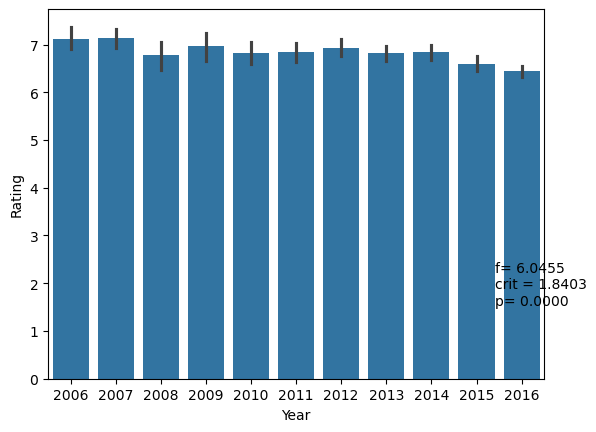

In [48]:
bar = sns.barplot(data=df, x="Year", y="Rating")
bar.text(x=0.9, y=0.2, s=f"f= {f:.4f}\ncrit = {critical:.4f}\np= {p:.4f}", transform = bar.transAxes)


Text(0.8, 0.8, 'f= 6.0455\ncrit = 1.8403\np= 0.0000')

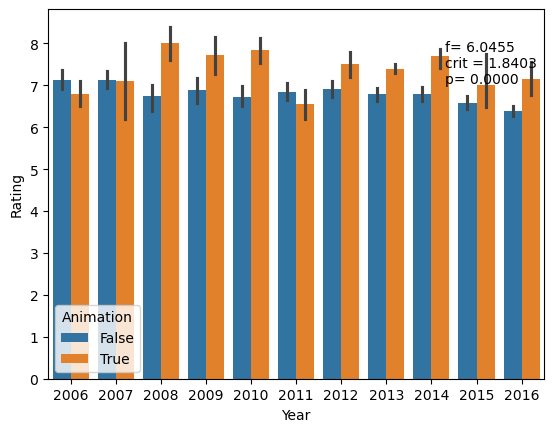

In [59]:
bar = sns.barplot(data=df, x="Year", y="Rating", hue="Animation")
bar.text(x=0.8, y=0.8, s=f"f= {f:.4f}\ncrit = {critical:.4f}\np= {p:.4f}", transform = bar.transAxes)

Text(0.7, 0.2, 'f= 6.0455\ncrit = 1.8403\np= 0.0000')

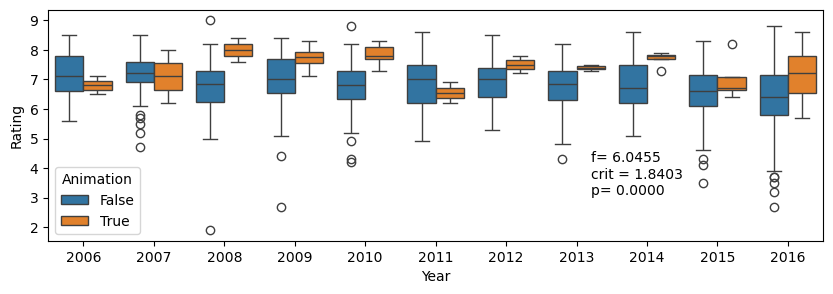

In [53]:
plt.figure(figsize=(10,3))
box = sns.boxplot(data=df, x="Year", y="Rating", hue="Animation")
box.text(x=0.7, y=0.2, s=f"f= {f:.4f}\ncrit = {critical:.4f}\np= {p:.4f}", transform = box.transAxes)


In [60]:
groups = [
    ["Action", "Adventure", "Sci-Fi"],
    ["Drama"],
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"],
]
df["Genre"] = df["Genre"].apply(lambda x: x.split(", "))
df["Genre"]

0       [Action,Adventure,Sci-Fi]
1      [Adventure,Mystery,Sci-Fi]
2               [Horror,Thriller]
3       [Animation,Comedy,Family]
4      [Action,Adventure,Fantasy]
                  ...            
995         [Crime,Drama,Mystery]
996                      [Horror]
997         [Drama,Music,Romance]
998            [Adventure,Comedy]
999       [Comedy,Family,Fantasy]
Name: Genre, Length: 1000, dtype: object

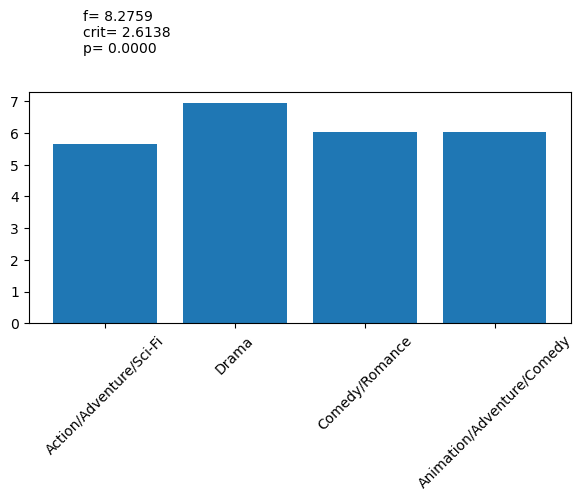

In [62]:
group_samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups]
f,p = stats.f_oneway(*group_samples)
dfb = len(group_samples) - 1
dfw = len(df) - len(group_samples)
crit = stats.f.ppf(1 - alpha, dfb, dfw)
text = f"""f= {f:.4f}
crit= {crit:.4f}
p= {p:.4f}
"""
plt.figure(figsize=(7,3))
cols = ["/".join(g) for g in groups]
heights = [s.mean() for s in group_samples]
plt.bar(x=cols, height=heights)
plt.text(x=0.1, y=1.1, s=text, transform=plt.gca().transAxes)
plt.xticks(rotation=45)
plt.show()

In [63]:
tukey = stats.tukey_hsd(*group_samples)
print(tukey)
print(group_samples)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -1.275     0.040    -2.511    -0.040
 (0 - 2)     -0.371     0.870    -1.636     0.893
 (0 - 3)     -0.373     0.867    -1.635     0.889
 (1 - 0)      1.275     0.040     0.040     2.511
 (1 - 2)      0.904     0.001     0.304     1.504
 (1 - 3)      0.902     0.001     0.307     1.497
 (2 - 0)      0.371     0.870    -0.893     1.636
 (2 - 1)     -0.904     0.001    -1.504    -0.304
 (2 - 3)     -0.002     1.000    -0.655     0.650
 (3 - 0)      0.373     0.867    -0.889     1.635
 (3 - 1)     -0.902     0.001    -1.497    -0.307
 (3 - 2)      0.002     1.000    -0.650     0.655

[123    7.4
183    5.9
580    4.9
616    4.0
949    6.1
Name: Rating, dtype: float64, 21     7.9
41     7.5
44     6.3
49     3.7
68     7.5
92     8.1
108    5.8
130    7.3
143    8.2
152    5.8
191    5.6
211    5.3
225    7.0
263    7.0
293    7.7
321    6.4
350    7.3
351    6.6
365    8.